# Road Sign Detection

here is where I reimplement the **object detection** part of my road sign detection and classification project,
picking up where `RoadsignClassifier.ipynb` left off. That notebook trains a
classifier on the same dataset but the earlier detection attempt (a from-scratch
`torchvision` Faster R-CNN training loop) was removed after repeated box/label
mismatch errors.

This version takes a different approach:

1. Load and **clean** the same dataset (`ThankGod/mapillary_traffic_sign_dataset`) used by the classifier.
2. Reuse the classifier's **20 super-class** grouping, but build it **deterministically** from the
   full dataset (the classifier's version was built from a random 500-image sample, which produced a
   different set of categories on every run).
3. Fine-tune **[`hustvl/yolos-tiny`](https://huggingface.co/hustvl/yolos-tiny)**, a small
   Vision-Transformer-based object detector (~6.5M parameters) that is light enough to fine-tune on in colab without it taking an eternity to train, outright crashing, or timing out.





## 1. Setup

Install the libraries needed for loading the dataset, fine-tuning an object detection model, computing
mAP/mAR, and (optionally) augmenting images with `albumentations`.


In [2]:
!pip install -q -U datasets transformers accelerate torchmetrics pycocotools albumentations matplotlib pillow


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.3/80.3 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 559.1/559.1 kB 15.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 37.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 139.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 141.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.1/50.1 MB 49.9 MB/s eta 0:00:00
^C


In [1]:
import os
import random
import numpy as np
import torch
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw

print(f"Torch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
else:
    print("No GPU detected - training will run on CPU. This will be slow; "
          "consider Runtime > Change runtime type > GPU if you're on Colab.")

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)


Torch version: 2.11.0+cu128
CUDA available: True
GPU: Tesla T4


## 2. Load the dataset

Same dataset as the classifier notebook: `ThankGod/mapillary_traffic_sign_dataset`. Each example has:
- `image`: a PIL image
- `objects`: a dict with parallel lists `bbox` (COCO `[x, y, w, h]` format) and `category` (integer
  category ids, ~260-290 fine-grained sign classes depending on what's present in the split)

The dataset ships with a single `train` split, so we'll create our own train/validation/test split
further down.


In [2]:
from datasets import load_dataset

ds = load_dataset("ThankGod/mapillary_traffic_sign_dataset")
print(ds)
print(f"\nAvailable splits: {list(ds.keys())}")
print(f"Number of examples in 'train': {len(ds['train'])}")
print(f"\nExample record keys: {ds['train'][0].keys()}")
print(f"Example 'objects' structure: {ds['train'][0]['objects']}")


README.md:   0%|          | 0.00/12.9k [00:00<?, ?B/s]

val_mtsd_new/train-00000-of-00007.parque(…): reconstructing file:   0%|          |  0.00B /  448MB            

val_mtsd_new/train-00000-of-00007.parque(…): downloading bytes:           |  0.00B            

val_mtsd_new/train-00001-of-00007.parque(…): reconstructing file:   0%|          |  0.00B /  454MB            

val_mtsd_new/train-00001-of-00007.parque(…): downloading bytes:           |  0.00B            

...

val_mtsd_new/train-00005-of-00007.parque(…): downloading bytes:           |  0.00B            

val_mtsd_new/train-00006-of-00007.parque(…): reconstructing file:   0%|          |  0.00B /  460MB            

val_mtsd_new/train-00006-of-00007.parque(…): downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/3813 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['image_id', 'image', 'width', 'height', 'objects'],
        num_rows: 3813
    })
})

Available splits: ['train']
Number of examples in 'train': 3813

Example record keys: dict_keys(['image_id', 'image', 'width', 'height', 'objects'])
Example 'objects' structure: {'bbox_id': [1, 2, 3, 4, 5], 'category': [157, 156, 325, 166, 259], 'bbox': [[1749.921875, 1723.0078125, 1824.0625, 1795.37109375], [3051.953125, 2057.40234375, 3117.96875, 2125.95703125], [2413.125, 1946.953125, 2483.203125, 2017.79296875], [1261.40625, 2008.65234375, 1311.171875, 2057.40234375], [3062.109375, 1964.47265625, 3130.15625, 2032.265625]], 'area': [5365.058898925781, 4525.6805419921875, 4964.323425292969, 2426.07421875, 4613.099670410156]}


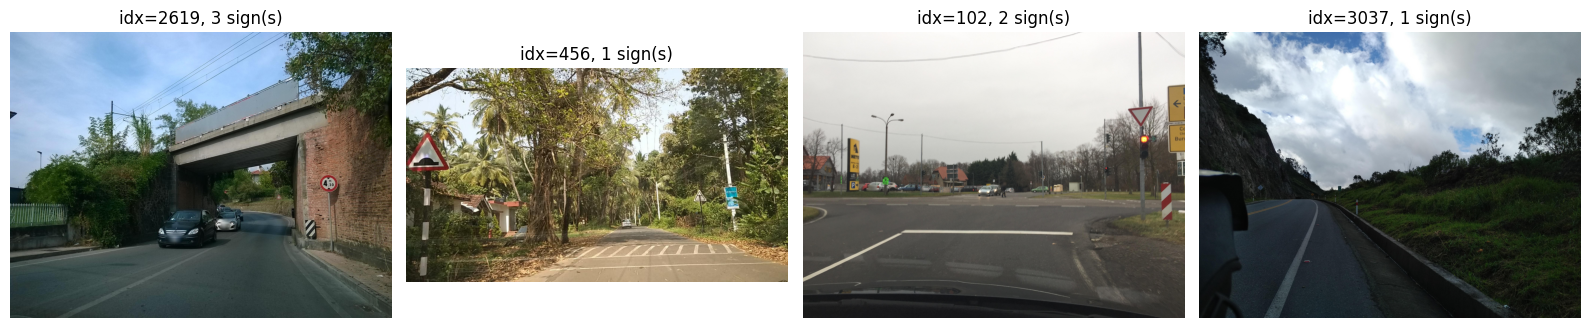

In [3]:
# Quick visual sanity check: a handful of raw images with their raw (unmapped) category ids
num_samples = 4
fig, axes = plt.subplots(1, num_samples, figsize=(4 * num_samples, 4))
for ax in axes:
    idx = random.randint(0, len(ds["train"]) - 1)
    sample = ds["train"][idx]
    ax.imshow(sample["image"])
    n_objects = len(sample["objects"]["category"]) if sample["objects"] else 0
    ax.set_title(f"idx={idx}, {n_objects} sign(s)")
    ax.axis("off")
plt.tight_layout()
plt.show()


## 3. Build the super-class mapping (deterministic, full-dataset)

The classifier notebook grouped the ~260-290 fine-grained sign categories into `num_super_classes = 20`
buckets, purely by sorted category id (there are no human-readable category names available in this
dataset's features). We keep that same scheme for consistency between the two notebooks, but fix the
non-determinism: instead of sampling 500 random images to discover categories, we scan the **entire**
dataset once, so the mapping is stable across runs.


In [4]:
NUM_SUPER_CLASSES = 20

# Scan the *entire* training split once (deterministic) rather than a random sample.
all_categories = set()
for objects in ds["train"]["objects"]:
    all_categories.update(objects["category"])

sorted_categories = sorted(all_categories)
num_granular = len(sorted_categories)
print(f"Found {num_granular} unique fine-grained category ids across the full dataset.")

# Distribute the granular categories as evenly as possible across NUM_SUPER_CLASSES buckets,
# in sorted-id order (same scheme as the classifier notebook).
class_mapping = {}
base, remainder = divmod(num_granular, NUM_SUPER_CLASSES)
cursor = 0
for super_id in range(NUM_SUPER_CLASSES):
    count = base + (1 if super_id < remainder else 0)
    for _ in range(count):
        if cursor >= num_granular:
            break
        class_mapping[sorted_categories[cursor]] = super_id
        cursor += 1

print(f"Mapped {len(class_mapping)} granular categories -> {len(set(class_mapping.values()))} super classes.")

id2label = {i: f"class_{i}" for i in range(NUM_SUPER_CLASSES)}
label2id = {v: k for k, v in id2label.items()}
print(id2label)


Found 389 unique fine-grained category ids across the full dataset.
Mapped 389 granular categories -> 20 super classes.
{0: 'class_0', 1: 'class_1', 2: 'class_2', 3: 'class_3', 4: 'class_4', 5: 'class_5', 6: 'class_6', 7: 'class_7', 8: 'class_8', 9: 'class_9', 10: 'class_10', 11: 'class_11', 12: 'class_12', 13: 'class_13', 14: 'class_14', 15: 'class_15', 16: 'class_16', 17: 'class_17', 18: 'class_18', 19: 'class_19'}


## 4. Clean and prepare the data for detection

For object detection we need to, per image:

- Drop annotations whose category isn't in our mapping (shouldn't happen since we scanned the full
  dataset, but kept as a safety net).
- Drop degenerate boxes (zero or negative width/height).
- **Clip boxes to the image bounds** — a few annotations in this dataset extend past the edges of the
  image, which silently corrupted the earlier Faster R-CNN attempt.
- Recompute box area (used by the COCO-style metric later) from the *cleaned* box, not the raw one.
- Drop any image left with **zero** valid boxes after cleaning, since an object detector needs at least
  one target per training image (a production pipeline could instead keep these as hard negatives, but
  we keep things simple here).

We also remap each box's category to its super-class id using the mapping built above.


In [5]:
def prepare_example(example, idx):
    image = example["image"]
    if image.mode != "RGB":
        image = image.convert("RGB")
    img_w, img_h = image.size

    objects = example["objects"] or {}
    raw_boxes = objects.get("bbox", [])
    raw_cats = objects.get("category", [])

    out_ids, out_boxes, out_cats, out_areas = [], [], [], []
    for i, (bbox, cat) in enumerate(zip(raw_boxes, raw_cats)):
        if cat not in class_mapping:
            continue
        x, y, w, h = bbox
        if w <= 0 or h <= 0:
            continue
        # Clip to image bounds
        x = max(0.0, min(x, img_w))
        y = max(0.0, min(y, img_h))
        w = min(w, img_w - x)
        h = min(h, img_h - y)
        if w <= 1 or h <= 1:  # drop slivers left over after clipping
            continue
        out_ids.append(i)
        out_boxes.append([x, y, w, h])
        out_cats.append(class_mapping[cat])
        out_areas.append(w * h)

    return {
        "image_id": idx,
        "image": image,
        "width": img_w,
        "height": img_h,
        "objects": {"id": out_ids, "bbox": out_boxes, "category": out_cats, "area": out_areas},
    }


ds_prepared = ds["train"].map(
    prepare_example, with_indices=True, remove_columns=ds["train"].column_names
)

n_before = len(ds_prepared)
ds_prepared = ds_prepared.filter(lambda x: len(x["objects"]["bbox"]) > 0)
n_after = len(ds_prepared)
print(f"Images before dropping empty ones: {n_before}")
print(f"Images after dropping empty ones:  {n_after}  ({n_before - n_after} dropped)")

total_boxes = sum(len(x["category"]) for x in ds_prepared["objects"])
print(f"Total cleaned bounding boxes: {total_boxes}")


Map:   0%|          | 0/3813 [00:00<?, ? examples/s]

Filter:   0%|          | 0/3813 [00:00<?, ? examples/s]

Images before dropping empty ones: 3813
Images after dropping empty ones:  3813  (0 dropped)
Total cleaned bounding boxes: 8737


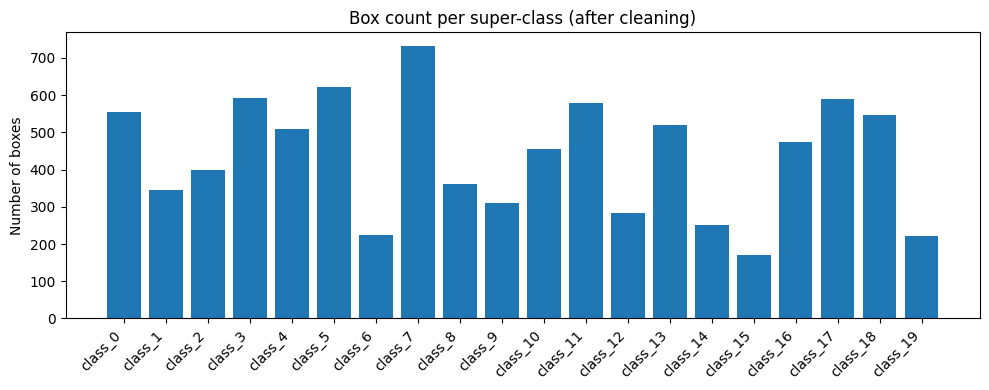

In [6]:
# Sanity check: class balance across the 20 super-classes after cleaning
from collections import Counter

counts = Counter()
for objects in ds_prepared["objects"]:
    counts.update(objects["category"])

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar([id2label[i] for i in range(NUM_SUPER_CLASSES)], [counts.get(i, 0) for i in range(NUM_SUPER_CLASSES)])
ax.set_ylabel("Number of boxes")
ax.set_title("Box count per super-class (after cleaning)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


## 5. Train / validation / test split

The dataset only provides a single split, so we create our own: 80% train, 10% validation,
10% test (the validation split is used for model selection during training, the held-out test
split is only touched once, at final evaluation).


In [7]:
split_a = ds_prepared.train_test_split(test_size=0.2, seed=SEED)
train_ds_raw = split_a["train"]

split_b = split_a["test"].train_test_split(test_size=0.5, seed=SEED)
val_ds_raw = split_b["train"]
test_ds_raw = split_b["test"]

print(f"Train: {len(train_ds_raw)}")
print(f"Validation: {len(val_ds_raw)}")
print(f"Test: {len(test_ds_raw)}")


Train: 3050
Validation: 381
Test: 382


## 6. Preprocessing for YOLOS

`AutoImageProcessor` for YOLOS resizes/normalizes images and converts our COCO-style annotations
(`{'image_id', 'annotations': [{'bbox', 'category_id', 'area', 'iscrowd'}, ...]}`) into the
normalized `pixel_values` / `labels` format the model expects.

For **augmentation**, we deliberately do **not** use a horizontal flip: several traffic sign
categories are direction-dependent (e.g. "turn left" vs "turn right" arrows), and flipping them
would silently create incorrect labels — a data-cleanliness issue that's easy to introduce by
copy-pasting a generic augmentation recipe. We stick to flips-free photometric and mild
perspective augmentation instead, applied to the training split only. The validation and test
splits stay augmentation-free so evaluation is deterministic.


In [8]:
from transformers import AutoImageProcessor

MODEL_NAME = "hustvl/yolos-tiny"
image_processor = AutoImageProcessor.from_pretrained(MODEL_NAME)
print(image_processor)


preprocessor_config.json:   0%|          | 0.00/291 [00:00<?, ?B/s]

YolosImageProcessor {
  "do_convert_annotations": true,
  "do_normalize": true,
  "do_pad": true,
  "do_rescale": true,
  "do_resize": true,
  "format": "coco_detection",
  "image_mean": [
    0.485,
    0.456,
    0.406
  ],
  "image_processor_type": "YolosImageProcessor",
  "image_std": [
    0.229,
    0.224,
    0.225
  ],
  "resample": 2,
  "rescale_factor": 0.00392156862745098,
  "size": {
    "longest_edge": 1333,
    "shortest_edge": 512
  }
}



In [9]:
import albumentations as A
from functools import partial


def format_image_annotations_as_coco(image_id, categories, areas, bboxes):
    annotations = []
    for category, area, bbox in zip(categories, areas, bboxes):
        annotations.append(
            {
                "image_id": image_id,
                "category_id": category,
                "iscrowd": 0,
                "area": area,
                "bbox": list(bbox),
            }
        )
    return {"image_id": image_id, "annotations": annotations}


def transform_batch(examples, image_processor):
    """Plain (no augmentation) transform - used for validation/test."""
    images, annotations = [], []
    for image_id, image, objects in zip(examples["image_id"], examples["image"], examples["objects"]):
        images.append(np.array(image.convert("RGB")))
        annotations.append(
            format_image_annotations_as_coco(image_id, objects["category"], objects["area"], objects["bbox"])
        )
    result = image_processor(images=images, annotations=annotations, return_tensors="pt")
    result.pop("pixel_mask", None)
    return result


# Flip-free augmentation: safe for direction-dependent traffic signs.
train_augment = A.Compose(
    [
        A.RandomBrightnessContrast(p=0.5),
        A.HueSaturationValue(p=0.2),
        A.Perspective(p=0.1, scale=(0.02, 0.05)),
    ],
    bbox_params=A.BboxParams(format="coco", label_fields=["category"], clip=True, min_area=16),
)


def augment_and_transform_batch(examples, image_processor, transform):
    images, annotations = [], []
    for image_id, image, objects in zip(examples["image_id"], examples["image"], examples["objects"]):
        image_np = np.array(image.convert("RGB"))
        output = transform(image=image_np, bboxes=objects["bbox"], category=objects["category"])
        images.append(output["image"])
        areas = [w * h for (_, _, w, h) in output["bboxes"]]
        annotations.append(
            format_image_annotations_as_coco(image_id, output["category"], areas, output["bboxes"])
        )
    result = image_processor(images=images, annotations=annotations, return_tensors="pt")
    result.pop("pixel_mask", None)
    return result


train_transform_fn = partial(augment_and_transform_batch, image_processor=image_processor, transform=train_augment)
eval_transform_fn = partial(transform_batch, image_processor=image_processor)

train_ds = train_ds_raw.with_transform(train_transform_fn)
val_ds = val_ds_raw.with_transform(eval_transform_fn)
test_ds = test_ds_raw.with_transform(eval_transform_fn)

# Quick check that a single example transforms without error
example = train_ds[0]
print({k: (v.shape if hasattr(v, "shape") else v) for k, v in example.items()})


{'pixel_values': torch.Size([3, 512, 672]), 'labels': {'size': tensor([512, 672]), 'image_id': tensor([2537]), 'class_labels': tensor([13]), 'boxes': tensor([[0.2827, 0.7949, 0.2007, 0.4102]]), 'area': tensor([28320.4688]), 'iscrowd': tensor([0]), 'orig_size': tensor([3488, 4656])}}


In [10]:
def collate_fn(batch):
    data = {}
    data["pixel_values"] = torch.stack([x["pixel_values"] for x in batch])
    data["labels"] = [x["labels"] for x in batch]
    if "pixel_mask" in batch[0]:
        data["pixel_mask"] = torch.stack([x["pixel_mask"] for x in batch])
    return data


## 7. mAP / mAR evaluation function

Standard COCO-style detection metrics via `torchmetrics`. The model predicts boxes in normalized
`(x_center, y_center, w, h)` format; we convert to absolute `(x_min, y_min, x_max, y_max)` before
scoring so that box areas (used to bucket small/medium/large objects) are computed correctly.


In [12]:
import torch
!pip install -q -U torchmetrics
from dataclasses import dataclass
from transformers.image_transforms import center_to_corners_format
from torchmetrics.detection.mean_ap import MeanAveragePrecision


def convert_bbox_yolo_to_pascal(boxes, image_size):
    boxes = center_to_corners_format(boxes)
    height, width = image_size
    boxes = boxes * torch.tensor([[width, height, width, height]])
    return boxes


@dataclass
class ModelOutput:
    logits: torch.Tensor
    pred_boxes: torch.Tensor


def _get_orig_size(image_target):
    orig = np.atleast_1d(np.asarray(image_target["orig_size"])).flatten()
    if len(orig) >= 2:
        return (int(orig[0]), int(orig[1]))
    return (int(orig[0]), int(orig[0]))


@torch.no_grad()
def compute_metrics(evaluation_results, image_processor, threshold=0.0, id2label=None):
    predictions, targets = evaluation_results.predictions, evaluation_results.label_ids
    image_sizes = []
    post_processed_targets = []
    post_processed_predictions = []

    for batch in targets:
        batch_sizes = []
        for image_target in batch:
            h, w = _get_orig_size(image_target)
            batch_sizes.append([h, w])
            boxes = torch.tensor(image_target["boxes"])
            boxes = convert_bbox_yolo_to_pascal(boxes, (h, w))
            labels = torch.tensor(image_target["class_labels"])
            post_processed_targets.append({"boxes": boxes, "labels": labels})
        image_sizes.append(torch.tensor(batch_sizes))

    for batch, target_sizes in zip(predictions, image_sizes):
        batch_logits, batch_boxes = batch[1], batch[2]
        output = ModelOutput(logits=torch.tensor(batch_logits), pred_boxes=torch.tensor(batch_boxes))
        post_processed_output = image_processor.post_process_object_detection(
            output, threshold=threshold, target_sizes=target_sizes
        )
        post_processed_predictions.extend(post_processed_output)

    metric = MeanAveragePrecision(box_format="xyxy", class_metrics=True)
    metric.update(post_processed_predictions, post_processed_targets)
    metrics = metric.compute()

    classes = metrics.pop("classes")
    map_per_class = metrics.pop("map_per_class")
    mar_100_per_class = metrics.pop("mar_100_per_class")
    for class_id, class_map, class_mar in zip(classes, map_per_class, mar_100_per_class):
        class_name = id2label[class_id.item()] if id2label is not None else class_id.item()
        metrics[f"map_{class_name}"] = class_map
        metrics[f"mar_100_{class_name}"] = class_mar

    metrics = {k: round(v.item(), 4) for k, v in metrics.items()}
    return metrics


eval_compute_metrics_fn = partial(
    compute_metrics, image_processor=image_processor, id2label=id2label, threshold=0.0
)

## 8. Load the model

`AutoModelForObjectDetection` swaps in a fresh classification head sized for our 20 super-classes
(`ignore_mismatched_sizes=True` is what allows replacing YOLOS's original COCO (91-class) head).


In [13]:
from transformers import AutoModelForObjectDetection

model = AutoModelForObjectDetection.from_pretrained(
    MODEL_NAME,
    id2label=id2label,
    label2id=label2id,
    ignore_mismatched_sizes=True,
)
n_params = sum(p.numel() for p in model.parameters())
print(f"Model: {MODEL_NAME}")
print(f"Total parameters: {n_params:,} (~{n_params / 1e6:.1f}M)")


config.json:   0%|          | 0.00/4.13k [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 26.0MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/211 [00:00<?, ?it/s]

[transformers] YolosForObjectDetection LOAD REPORT from: hustvl/yolos-tiny
Key                                     | Status   |                                                                                         
----------------------------------------+----------+-----------------------------------------------------------------------------------------
class_labels_classifier.layers.2.bias   | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([92]) vs model:torch.Size([21])          
class_labels_classifier.layers.2.weight | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([92, 192]) vs model:torch.Size([21, 192])

Notes:
- MISMATCH:	ckpt weights were loaded, but they did not match the original empty weight shapes.


Model: hustvl/yolos-tiny
Total parameters: 6,475,033 (~6.5M)


## 9. Train

Hyperparameters are tuned for a "modest PC / free Colab GPU" budget: small batch size, a small
number of epochs (this is a small dataset and a small model, so it converges quickly), and mixed
precision only when a GPU is actually available.

Using `transformers.Trainer` here (rather than a hand-written loop) sidesteps the class of bugs
that sank the earlier Faster R-CNN attempt: `Trainer` handles device placement, gradient
accumulation, and evaluation-batch bookkeeping for variable numbers of boxes per image itself.


In [16]:
import torch
from transformers import TrainingArguments, Trainer

OUTPUT_DIR = "yolos-tiny-roadsign-detector"

training_args = TrainingArguments(
    output_dir=OUTPUT_DIR,
    num_train_epochs=15,
    per_device_train_batch_size=4,
    per_device_eval_batch_size=4,
    dataloader_num_workers=2,
    learning_rate=5e-5,
    lr_scheduler_type="cosine",
    weight_decay=1e-4,
    max_grad_norm=0.01,
    fp16=torch.cuda.is_available(),
    metric_for_best_model="eval_map",
    greater_is_better=True,
    load_best_model_at_end=True,
    eval_strategy="epoch",
    save_strategy="epoch",
    save_total_limit=2,
    remove_unused_columns=False,   # needed so the image column survives for pixel_values
    eval_do_concat_batches=False,  # each image can have a different number of boxes
    report_to="none",
    push_to_hub=False,
    logging_steps=20,
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    processing_class=image_processor,
    data_collator=collate_fn,
    compute_metrics=eval_compute_metrics_fn,
)

train_result = trainer.train()


Epoch,Training Loss,Validation Loss,Map,Map 50,Map 75,Map Small,Map Medium,Map Large,Mar 1,Mar 10,Mar 100,Mar Small,Mar Medium,Mar Large,Map Class 0,Mar 100 Class 0,Map Class 1,Mar 100 Class 1,Map Class 2,Mar 100 Class 2,Map Class 3,Mar 100 Class 3,Map Class 4,Mar 100 Class 4,Map Class 5,Mar 100 Class 5,Map Class 6,Mar 100 Class 6,Map Class 7,Mar 100 Class 7,Map Class 8,Mar 100 Class 8,Map Class 9,Mar 100 Class 9,Map Class 10,Mar 100 Class 10,Map Class 11,Mar 100 Class 11,Map Class 12,Mar 100 Class 12,Map Class 13,Mar 100 Class 13,Map Class 14,Mar 100 Class 14,Map Class 15,Mar 100 Class 15,Map Class 16,Mar 100 Class 16,Map Class 17,Mar 100 Class 17,Map Class 18,Mar 100 Class 18,Map Class 19,Mar 100 Class 19
1,1.489325,1.529042,0.001500,0.003100,0.001500,-1.000000,0.000000,0.001500,0.024300,0.068800,0.085900,-1.000000,0.000000,0.085900,0.000300,0.021700,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.012100,0.301800,0.000000,0.000000,0.010000,0.687700,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000600,0.115400,0.000000,0.000000,0.006100,0.528600,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.001000,0.062900,0.000000,0.000000
2,1.496055,1.345884,0.002400,0.004600,0.002300,-1.000000,0.000000,0.002400,0.042700,0.087100,0.109200,-1.000000,0.000000,0.109200,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000700,0.042000,0.006100,0.045700,0.012600,0.509100,0.000000,0.000000,0.017900,0.768400,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.003600,0.459600,0.000000,0.000000,0.000300,0.014300,0.000000,0.000000,0.000000,0.000000,0.000700,0.005400,0.000000,0.000000,0.005700,0.340000,0.000000,0.000000
3,1.308717,1.299259,0.002000,0.004300,0.001800,-1.000000,0.000000,0.002000,0.041600,0.071100,0.093300,-1.000000,0.000000,0.093300,0.004000,0.260000,0.000000,0.000000,0.000000,0.000000,0.002000,0.070000,0.003000,0.026100,0.003700,0.041800,0.000000,0.000000,0.018700,0.768400,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.002100,0.419200,0.000000,0.000000,0.005700,0.188600,0.000000,0.000000,0.000000,0.000000,0.001700,0.091100,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
4,1.431383,1.363377,0.001900,0.004100,0.001200,-1.000000,0.200000,0.001900,0.038400,0.065000,0.080500,-1.000000,0.200000,0.080500,0.002600,0.018300,0.000000,0.000000,0.000000,0.000000,0.002000,0.184000,0.002900,0.152200,0.001100,0.058200,0.000000,0.000000,0.021900,0.819300,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000900,0.169200,0.000000,0.000000,0.003300,0.131400,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.003000,0.077900,0.000000,0.000000,0.000000,0.000000
5,1.490074,1.313748,0.002800,0.005400,0.002500,-1.000000,0.000000,0.002800,0.030000,0.060400,0.080800,-1.000000,0.000000,0.080800,0.003600,0.143300,0.000000,0.000000,0.000000,0.000000,0.000400,0.026000,0.011600,0.039100,0.001200,0.067300,0.000000,0.000000,0.032400,0.843900,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.002000,0.396200,0.000000,0.000000,0.002800,0.065700,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.002300,0.033700,0.000000,0.000000,0.000000,0.000000
6,1.373703,1.262141,0.004400,0.007300,0.004600,-1.000000,0.000000,0.004900,0.037900,0.063400,0.083900,-1.000000,0.000000,0.084000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.001100,0.048000,0.005800,0.056500,0.018500,0.621800,0.000000,0.000000,0.019900,0.678900,0.000000,0.000000,0.000000,0.000000,0.029400,0.055300,0.000400,0.030800,0.000000,0.000000,0.006100,0.060000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.006900,0.126700,0.000000,0.000000,0.000000,0.000000
7,1.160715,1.208913,0.003000,0.007500,0.002600,-1.000000,0.000000,0.003000,0.048200,0.083100,0.108800,-1.000000,0.000000,0.108800,0.009000,0.321700,0.000000,0.000000,0.001700,0.018900,0.005200,0.456000,0.002900,0.108700,0.006300,0.087300,0.000000,0.000000,0.014100,0.487700,0.000000,0.000000,0.000000,0.000000,0.008600,0.034000,0.002600,0.5654

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

## 10. Evaluate on the held-out test set

The validation split was used for model selection (`load_best_model_at_end`) during training; the
test split has not been touched until now, so this is an unbiased estimate of performance.


In [17]:
from pprint import pprint

test_metrics = trainer.evaluate(eval_dataset=test_ds, metric_key_prefix="test")
pprint(test_metrics)


Training Loss,Validation Loss,Epoch,Map,Map 50,Map 75,Map Small,Map Medium,Map Large,Mar 1,Mar 10,Mar 100,Mar Small,Mar Medium,Mar Large,Map Class 0,Mar 100 Class 0,Map Class 1,Mar 100 Class 1,Map Class 2,Mar 100 Class 2,Map Class 3,Mar 100 Class 3,Map Class 4,Mar 100 Class 4,Map Class 5,Mar 100 Class 5,Map Class 6,Mar 100 Class 6,Map Class 7,Mar 100 Class 7,Map Class 8,Mar 100 Class 8,Map Class 9,Mar 100 Class 9,Map Class 10,Mar 100 Class 10,Map Class 11,Mar 100 Class 11,Map Class 12,Mar 100 Class 12,Map Class 13,Mar 100 Class 13,Map Class 14,Mar 100 Class 14,Map Class 15,Mar 100 Class 15,Map Class 16,Mar 100 Class 16,Map Class 17,Mar 100 Class 17,Map Class 18,Mar 100 Class 18,Map Class 19,Mar 100 Class 19
1.042804,1.131944,15,0.011600,0.016100,0.011500,-1.000000,-1.000000,0.011600,0.076400,0.127400,0.148500,-1.000000,-1.000000,0.148500,0.008300,0.263000,0.000000,0.000000,0.000700,0.020500,0.022700,0.266200,0.021400,0.105300,0.051700,0.395300,0.000000,0.000000,0.056700,0.688200,0.000000,0.000000,0.000000,0.000000,0.039300,0.191200,0.008200,0.550800,0.000000,0.000000,0.011800,0.140400,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.008600,0.305700,0.002200,0.044400,0.000000,0.000000


{'test_loss': 1.131943941116333,
 'test_map': 0.0116,
 'test_map_50': 0.0161,
 'test_map_75': 0.0115,
 'test_map_class_0': 0.0083,
 'test_map_class_1': 0.0,
 'test_map_class_10': 0.0393,
 'test_map_class_11': 0.0082,
 'test_map_class_12': 0.0,
 'test_map_class_13': 0.0118,
 'test_map_class_14': 0.0,
 'test_map_class_15': 0.0,
 'test_map_class_16': 0.0,
 'test_map_class_17': 0.0086,
 'test_map_class_18': 0.0022,
 'test_map_class_19': 0.0,
 'test_map_class_2': 0.0007,
 'test_map_class_3': 0.0227,
 'test_map_class_4': 0.0214,
 'test_map_class_5': 0.0517,
 'test_map_class_6': 0.0,
 'test_map_class_7': 0.0567,
 'test_map_class_8': 0.0,
 'test_map_class_9': 0.0,
 'test_map_large': 0.0116,
 'test_map_medium': -1.0,
 'test_map_small': -1.0,
 'test_mar_1': 0.0764,
 'test_mar_10': 0.1274,
 'test_mar_100': 0.1485,
 'test_mar_100_class_0': 0.263,
 'test_mar_100_class_1': 0.0,
 'test_mar_100_class_10': 0.1912,
 'test_mar_100_class_11': 0.5508,
 'test_mar_100_class_12': 0.0,
 'test_mar_100_class_13'

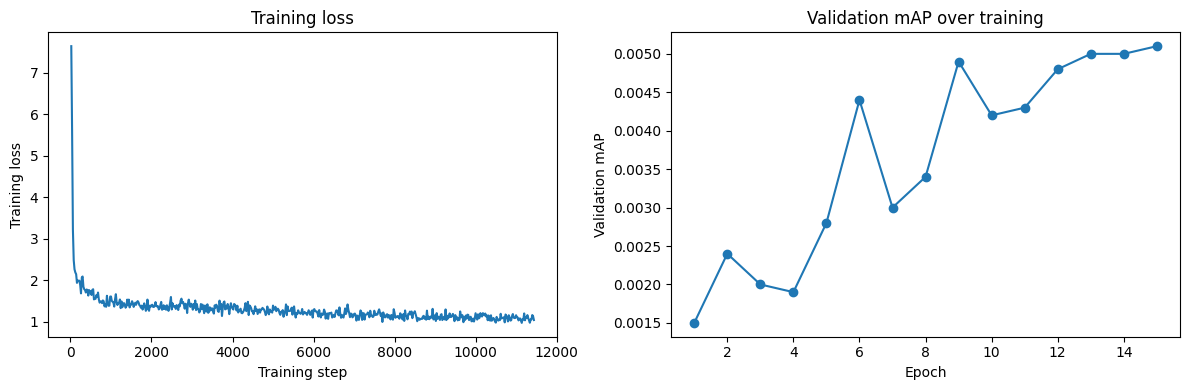

In [18]:
# Plot training/validation loss and mAP curves from the Trainer's log history
history = trainer.state.log_history

train_steps = [h["step"] for h in history if "loss" in h]
train_losses = [h["loss"] for h in history if "loss" in h]

eval_epochs = [h["epoch"] for h in history if "eval_map" in h]
eval_maps = [h["eval_map"] for h in history if "eval_map" in h]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(train_steps, train_losses)
axes[0].set_xlabel("Training step")
axes[0].set_ylabel("Training loss")
axes[0].set_title("Training loss")

axes[1].plot(eval_epochs, eval_maps, marker="o")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Validation mAP")
axes[1].set_title("Validation mAP over training")
plt.tight_layout()
plt.show()


## 11. Visualize predictions

A few images from the test set, with **ground-truth** boxes (green) and the model's
**predictions** (red, above a confidence threshold) drawn side by side.


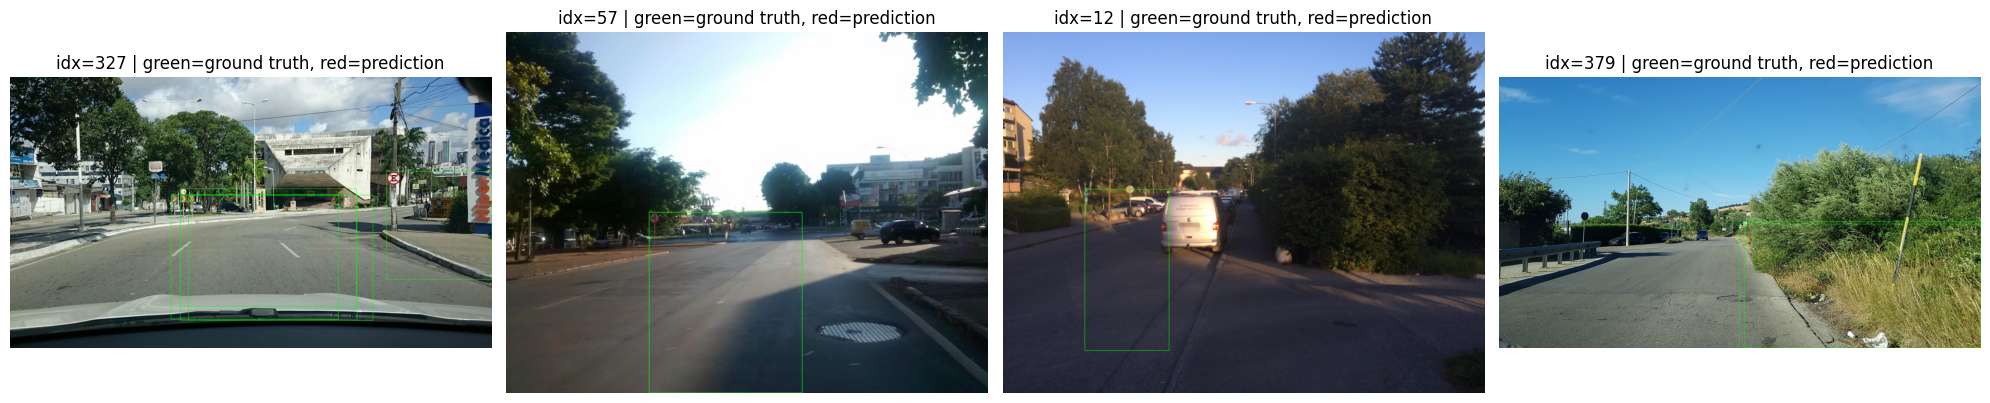

In [19]:
def draw_boxes(image, boxes, labels, color, scores=None):
    image = image.copy()
    draw = ImageDraw.Draw(image)
    for i, (box, label) in enumerate(zip(boxes, labels)):
        x0, y0, x1, y1 = [round(v) for v in box]
        draw.rectangle((x0, y0, x1, y1), outline=color, width=3)
        text = id2label.get(int(label), str(label))
        if scores is not None:
            text += f" {scores[i]:.2f}"
        draw.text((x0, max(0, y0 - 12)), text, fill=color)
    return image


model.eval()
model.to(DEVICE)

num_show = 4
indices = random.sample(range(len(test_ds_raw)), min(num_show, len(test_ds_raw)))

fig, axes = plt.subplots(1, num_show, figsize=(5 * num_show, 5))
if num_show == 1:
    axes = [axes]

for ax, idx in zip(axes, indices):
    raw = test_ds_raw[idx]
    image = raw["image"].convert("RGB")

    # Ground truth
    gt_boxes_xywh = raw["objects"]["bbox"]
    gt_boxes_xyxy = [[x, y, x + w, y + h] for (x, y, w, h) in gt_boxes_xywh]
    gt_labels = raw["objects"]["category"]
    vis = draw_boxes(image, gt_boxes_xyxy, gt_labels, color="lime")

    # Prediction
    with torch.no_grad():
        inputs = image_processor(images=[image], return_tensors="pt").to(DEVICE)
        outputs = model(**inputs)
        target_sizes = torch.tensor([[image.size[1], image.size[0]]])
        results = image_processor.post_process_object_detection(
            outputs, threshold=0.5, target_sizes=target_sizes
        )[0]

    pred_boxes = results["boxes"].cpu().tolist()
    pred_labels = results["labels"].cpu().tolist()
    pred_scores = results["scores"].cpu().tolist()
    vis = draw_boxes(vis, pred_boxes, pred_labels, color="red", scores=pred_scores)

    ax.imshow(vis)
    ax.set_title(f"idx={idx} | green=ground truth, red=prediction")
    ax.axis("off")

plt.tight_layout()
plt.show()


## 12. Save the model

Save the fine-tuned model and its image processor locally so they can be reloaded later without
retraining (or uploaded to the Hugging Face Hub with `trainer.push_to_hub()` if you set up
`huggingface_hub` login and `push_to_hub=True` above).


In [20]:
trainer.save_model(OUTPUT_DIR)
image_processor.save_pretrained(OUTPUT_DIR)
print(f"Model and image processor saved to ./{OUTPUT_DIR}")

# Reload example:
# from transformers import AutoImageProcessor, AutoModelForObjectDetection
# reloaded_processor = AutoImageProcessor.from_pretrained(OUTPUT_DIR)
# reloaded_model = AutoModelForObjectDetection.from_pretrained(OUTPUT_DIR)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model and image processor saved to ./yolos-tiny-roadsign-detector


## Summary & next steps

After finally getting this part of the project to work, I have a few thoughts. Firstly, the major roadblock I had was with preparing the dataset specifically for this task. After running this through claude, it found out *why* I was running into these issues. There were a few box/label mismatch bugs within the dataset that caused these issues for this task. Which makes sense why I had a much easier time with classification. Secondly, looking at the model performance, I found that it was not very accurate. This is due to the size of the model, and I expected this to happen to a degree. In a future iteration, I will likely use yolos-small instead of yolos-tiny. The main reason why I chose tiny was the fact that I did not want the model to crash or time out during training, and to make sure that everything else was functioning properly. I might also use the original fine-grained categories in the next version of this, but for now, it works and I am happy with that.
